# EEG Biometric Authentication — Riemannian Potato

Enrolled on **both ziyang sessions (1230 + 1400)** combined.

Tests:
- ziyang 1230 + 1400 (self) → ACCEPT
- chris 1230 + 1400 (impostor) → REJECT

In [1]:
import sys; sys.path.insert(0, '/home/josua/Projects/hackathon_zeiss/brain_id')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from auth import (load_csv, preprocess, epoch, to_covs,
                  enroll_multi, verify_multi,
                  OCC_CHANNELS, RATE_TO_FREQ,
                  save_potatoes, load_potatoes)
RATES = ['10hz', '15hz']
print('imports ok')

imports ok


## 1. Enroll — ziyang 1230 (narrow bandpass + CAR + occipital channels ch5–ch8)

In [2]:
ENROLL_CSVS = {
    '10hz': '../data/raw/1230_ziyang_10hz.csv',
    '15hz': '../data/raw/1230_ziyang_15hz.csv',
}

# enroll_multi auto-applies narrow bandpass per rate + CAR + occipital channels
potatoes = enroll_multi(ENROLL_CSVS)
save_potatoes(potatoes, '../models/ziyang_potatoes_v2.pkl')
print('Enrollment done.')

  enrollment: 128 clean epochs  [1230_ziyang_10hz.csv]
  enrollment: 130 clean epochs  [1230_ziyang_15hz.csv]


Saved ['10hz', '15hz'] → ../models/ziyang_potatoes_v2.pkl
Enrollment done.


## 2. Verify — collect z-scores per subject × rate

In [3]:
TEST_CSVS = {
    'ziyang_1230': {'10hz': '../data/raw/1230_ziyang_10hz.csv',
                    '15hz': '../data/raw/1230_ziyang_15hz.csv'},
    'ziyang_1400': {'10hz': '../data/raw/1400_ziyang_10hz.csv',
                    '15hz': '../data/raw/1400_ziyang_15hz.csv'},
    'chris_1400':  {'10hz': '../data/raw/1400_chris_10hz.csv',
                    '15hz': '../data/raw/1400_chris_15hz.csv'},
    'chris_1600':  {'10hz': '../data/raw/1600_chris_10hz.csv'},
    'josua_1600':  {'10hz': '../data/raw/1600_josua_10hz.csv'},
}

zscores = {}; results = {}
for subject, rate_csvs in TEST_CSVS.items():
    zscores[subject] = {}; results[subject] = {}
    for rate, path in rate_csvs.items():
        if rate not in potatoes:
            continue
        ssvep_freq = RATE_TO_FREQ.get(rate)
        X = preprocess(load_csv(path, OCC_CHANNELS), ssvep_freq)
        covs = to_covs(epoch(X))
        zscores[subject][rate] = potatoes[rate].transform(covs)
        results[subject][rate] = {
            'decision':    'ACCEPT' if (potatoes[rate].predict(covs).mean() > 0.5) else 'REJECT',
            'accept_rate': round(float(potatoes[rate].predict(covs).mean()), 3),
            'mean_zscore': round(float(zscores[subject][rate].mean()), 3),
            'n_epochs':    len(covs),
        }
print('Verification done.')

  artifact rejection: dropped 1/78 epochs
Verification done.


## 3. Summary table

In [4]:
rows = []
for subject, rate_results in results.items():
    for rate, r in rate_results.items():
        rows.append({'subject': subject, 'rate': rate, 'decision': r['decision'],
                     'accept_rate': r['accept_rate'], 'mean_zscore': r['mean_zscore'],
                     'n_epochs': r['n_epochs']})
df = pd.DataFrame(rows)
def color_decision(val):
    return 'background-color: #c8e6c9' if val == 'ACCEPT' else 'background-color: #ffcdd2'
df.style.map(color_decision, subset=['decision'])

,subject,rate,decision,accept_rate,mean_zscore,n_epochs
0,ziyang_1230,10hz,ACCEPT,0.977000,0.106000,128
1,ziyang_1230,15hz,ACCEPT,0.954000,0.186000,130
2,ziyang_1400,10hz,ACCEPT,0.706000,1.853000,68
3,ziyang_1400,15hz,ACCEPT,0.667000,2.173000,66
4,chris_1400,10hz,REJECT,0.424000,2.740000,139
5,chris_1400,15hz,ACCEPT,0.592000,2.335000,130
6,chris_1600,10hz,ACCEPT,0.792000,2.234000,77
7,josua_1600,10hz,ACCEPT,0.605000,2.414000,81


## 4. Z-score distributions per rate

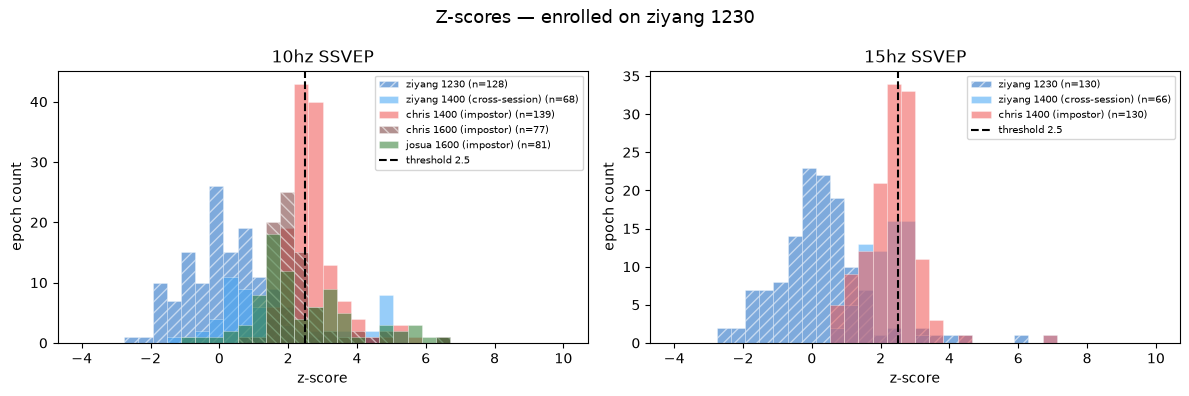

In [5]:
SUBJECT_STYLE = {
    'ziyang_1230': ('#1565C0', '///', 'ziyang 1230'),
    'ziyang_1400': ('#42A5F5', '',    'ziyang 1400 (cross-session)'),
    'chris_1400':  ('#EF5350', '',    'chris 1400 (impostor)'),
    'chris_1600':  ('#743736', '\\\\\\', 'chris 1600 (impostor)'),
    'josua_1600':  ('#2E7D32', '',    'josua 1600 (impostor)'),
}
fig, axes = plt.subplots(1, len(RATES), figsize=(6 * len(RATES), 4))
fig.suptitle('Z-scores — enrolled on ziyang 1230', fontsize=13)
bins = np.linspace(-4, 10, 35)
for ax, rate in zip(axes, RATES):
    for subject, (color, hatch, label) in SUBJECT_STYLE.items():
        z = zscores.get(subject, {}).get(rate)
        if z is None: continue
        ax.hist(z, bins=bins, alpha=0.55, color=color, hatch=hatch,
                label=f'{label} (n={len(z)})', edgecolor='white', linewidth=0.4)
    ax.axvline(2.5, color='black', linewidth=1.5, linestyle='--', label='threshold 2.5')
    ax.set_title(f'{rate} SSVEP'); ax.set_xlabel('z-score'); ax.set_ylabel('epoch count')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('../reports/figures/08_zscore_2sessions.png', dpi=150)
plt.show()

## 5. Accept rate — does chris still get rejected?

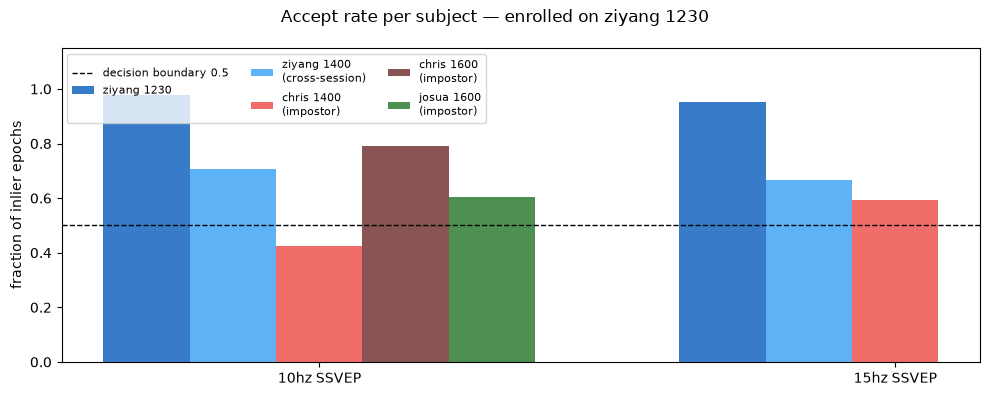

In [6]:
subjects_ordered = ['ziyang_1230', 'ziyang_1400', 'chris_1400', 'chris_1600', 'josua_1600']
labels_ordered   = ['ziyang 1230', 'ziyang 1400\n(cross-session)',
                    'chris 1400\n(impostor)', 'chris 1600\n(impostor)', 'josua 1600\n(impostor)']
bar_colors       = ['#1565C0', '#42A5F5', '#EF5350', '#743736', '#2E7D32']
x = np.arange(len(RATES)); width = 0.15
offsets = np.linspace(-2, 2, len(subjects_ordered)) * width
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Accept rate per subject — enrolled on ziyang 1230', fontsize=12)
for i, (subject, label, color) in enumerate(zip(subjects_ordered, labels_ordered, bar_colors)):
    vals = [results.get(subject, {}).get(rate, {}).get('accept_rate', np.nan) for rate in RATES]
    ax.bar(x + offsets[i], vals, width, label=label, color=color, alpha=0.85)
ax.axhline(0.5, color='black', linewidth=1, linestyle='--', label='decision boundary 0.5')
ax.set_xticks(x); ax.set_xticklabels([f'{r} SSVEP' for r in RATES])
ax.set_ylabel('fraction of inlier epochs'); ax.set_ylim(0, 1.15)
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig('../reports/figures/09_accept_rates_2sessions.png', dpi=150)
plt.show()

## 6. PCA (n=3) of covariance matrices — 5 Hz (narrow bandpass + CAR + occipital ch5–ch8)

  artifact rejection: dropped 1/78 epochs
Explained variance: PC1=41.3%  PC2=35.1%  PC3=10.0%  total=86.4%


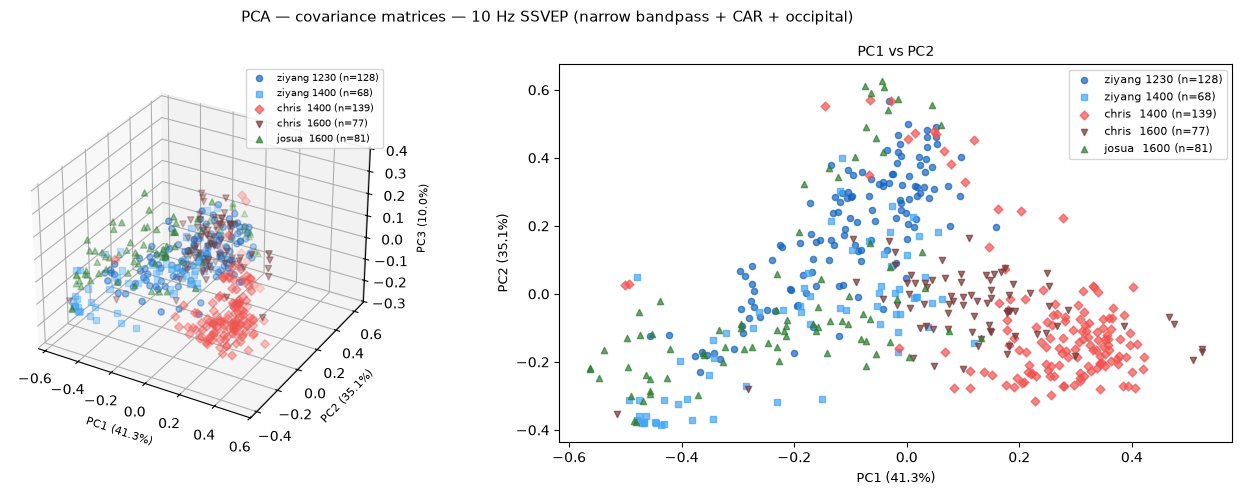

In [7]:
from sklearn.decomposition import PCA

groups = {
    'ziyang 1230': '../data/raw/1230_ziyang_10hz.csv',
    'ziyang 1400': '../data/raw/1400_ziyang_10hz.csv',
    'chris  1400': '../data/raw/1400_chris_10hz.csv',
    'chris  1600': '../data/raw/1600_chris_10hz.csv',
    'josua  1600': '../data/raw/1600_josua_10hz.csv',
}
colors  = {'ziyang 1230': '#1565C0', 'ziyang 1400': '#42A5F5',
           'chris  1400': '#EF5350', 'chris  1600': '#743736',
           'josua  1600': '#2E7D32'}
markers = {'ziyang 1230': 'o', 'ziyang 1400': 's',
           'chris  1400': 'D', 'chris  1600': 'v',
           'josua  1600': '^'}

def covs_preprocessed(csv_path, ssvep_freq=10.0):
    X = load_csv(csv_path, OCC_CHANNELS)
    X = preprocess(X, ssvep_freq=ssvep_freq)
    return to_covs(epoch(X))

n_ch = len(OCC_CHANNELS)
idx = np.triu_indices(n_ch, k=0)
all_vecs, all_labels, group_sizes = [], [], {}
for name, path in groups.items():
    covs = covs_preprocessed(path)
    vecs = covs[:, idx[0], idx[1]]
    all_vecs.append(vecs)
    all_labels.extend([name] * len(vecs))
    group_sizes[name] = len(vecs)

X_all = np.vstack(all_vecs)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_all)
var = pca.explained_variance_ratio_ * 100
print(f'Explained variance: PC1={var[0]:.1f}%  PC2={var[1]:.1f}%  PC3={var[2]:.1f}%  total={sum(var):.1f}%')

fig = plt.figure(figsize=(14, 5))
fig.suptitle('PCA — covariance matrices — 10 Hz SSVEP (narrow bandpass + CAR + occipital)', fontsize=11)
ax3d = fig.add_subplot(121, projection='3d')
ax2d = fig.add_subplot(122)

start = 0
for name in groups:
    n = group_sizes[name]
    pts = X_pca[start:start+n]
    kw = dict(c=colors[name], marker=markers[name], s=20, alpha=0.7, label=f'{name} (n={n})')
    ax3d.scatter(pts[:,0], pts[:,1], pts[:,2], **kw)
    ax2d.scatter(pts[:,0], pts[:,1], **kw)
    start += n

ax3d.set_xlabel(f'PC1 ({var[0]:.1f}%)', fontsize=8)
ax3d.set_ylabel(f'PC2 ({var[1]:.1f}%)', fontsize=8)
ax3d.set_zlabel(f'PC3 ({var[2]:.1f}%)', fontsize=8)
ax3d.legend(fontsize=7)
ax2d.set_xlabel(f'PC1 ({var[0]:.1f}%)', fontsize=9)
ax2d.set_ylabel(f'PC2 ({var[1]:.1f}%)', fontsize=9)
ax2d.set_title('PC1 vs PC2', fontsize=10)
ax2d.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/12_pca_10hz.png', dpi=150)
plt.show()